# Russian River Streamflow Forecasting — End-to-End Walkthrough

A 30-year analysis of the Russian River near Hopland (USGS gauge **11462500**, drainage area **937 km²**) using only free, no-auth public data:

* USGS NWIS daily streamflow
* Open-Meteo Historical (ERA5) daily precipitation, T_max, T_min
* Hargreaves–Samani PET from temperature

The pipeline runs in five steps, mirroring the scripts in `scripts/`:

1. Load the cached daily forcing record
2. Calibrate with Differential Evolution; validate on a held-out half
3. Regional Sensitivity Analysis on 5,000 LHS samples
4. GLUE uncertainty bands
5. Climate-change scenarios

Re-run all cells to regenerate the analysis from scratch.


In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from scipy.stats import qmc

from src.data_acquisition import load_cached, RUSSIAN_RIVER_HOPLAND
from src.hydro_model import simulate, Parameters, PARAMETER_BOUNDS, PARAMETER_NAMES
from src.metrics import all_metrics, kge

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})


## 1. Load the data

`scripts/01_fetch_data.py` already fetched and cached 30 water years of
forcings + observed streamflow as `data/processed/catchment_daily.csv`.
Re-run that script to refresh.


In [2]:
df = load_cached(RUSSIAN_RIVER_HOPLAND)
print(f'{len(df):,} daily records  '
      f'{df["date"].min().date()} → {df["date"].max().date()}')
df.head(5)


10,958 daily records  1995-01-01 → 2024-12-31


,date,P_mm,T_max_C,T_min_C,T_mean_C,Q_cfs,Q_mm,PET_mm
0,1995-01-01,10.5,8.8,5.9,7.35,221.0,0.577046,0.581266
1,1995-01-02,3.4,11.6,5.4,8.50,244.0,0.637101,0.892179
2,1995-01-03,18.1,9.7,6.6,8.15,431.0,1.125371,0.625039
3,1995-01-04,21.2,7.5,5.3,6.40,718.0,1.874747,0.493206
4,1995-01-05,14.0,9.3,4.7,7.00,1790.0,4.673813,0.734289


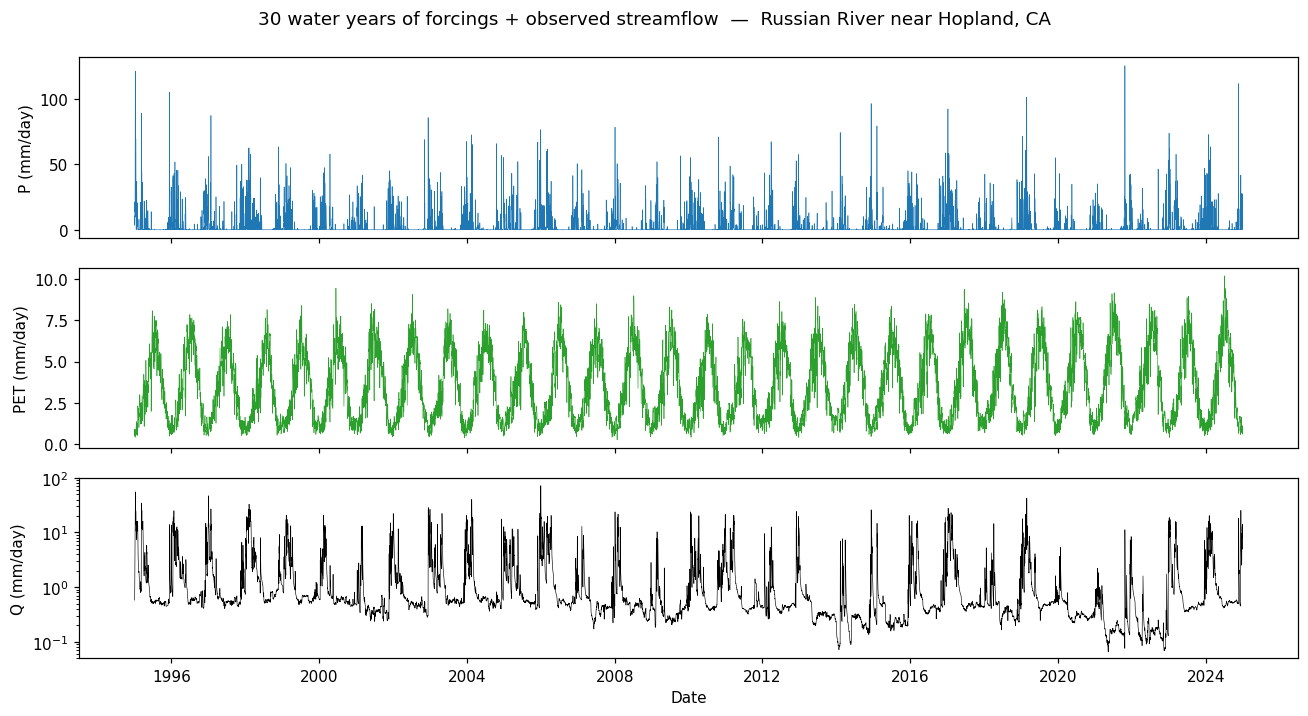

In [3]:
fig, ax = plt.subplots(3, 1, figsize=(12, 6.5), sharex=True)
ax[0].plot(df['date'], df['P_mm'], color='#1F77B4', lw=0.4)
ax[0].set_ylabel('P (mm/day)')
ax[1].plot(df['date'], df['PET_mm'], color='#2CA02C', lw=0.4)
ax[1].set_ylabel('PET (mm/day)')
ax[2].plot(df['date'], df['Q_mm'], color='black', lw=0.4)
ax[2].set_yscale('log')
ax[2].set_ylim(0.05, 100)
ax[2].set_ylabel('Q (mm/day)')
ax[2].set_xlabel('Date')
plt.suptitle(f'30 water years of forcings + observed streamflow  —  {RUSSIAN_RIVER_HOPLAND.name}', y=0.995)
plt.tight_layout()
plt.show()


## 2. Calibration + split-sample validation

Calibration: 1995-10-01 → 2009-09-30 (14 water years).
Validation:  2010-10-01 → 2024-09-30 (14 water years, held out).


In [4]:
calibration = json.loads((ROOT / 'data' / 'processed' / 'calibration_results.json').read_text())
print('Optimal parameters:')
for k, v in calibration['parameters'].items():
    print(f'  {k:8s} = {v:.3f}')
print()
print('Goodness of fit:')
print(f"  {'metric':8s}  {'cal':>8s}  {'val':>8s}")
for m in ['NSE', 'KGE', 'logNSE', 'PBIAS']:
    c = calibration['calibration']['metrics'][m]
    v = calibration['validation']['metrics'][m]
    print(f"  {m:8s}  {c:8.3f}  {v:8.3f}")


Optimal parameters:
  S_max    = 247.974
  f_quick  = 0.229
  k_perc   = 0.004
  tau_b    = 17.446
  gamma    = 2.844

Goodness of fit:
  metric         cal       val
  NSE          0.770     0.539
  KGE          0.885     0.537
  logNSE       0.724     0.518
  PBIAS       -0.107    33.337


The KGE drops from **0.88** in calibration to **0.54** in validation, with a
+33 % bias. This is non-stationarity at work: the post-2010 record is
notably drier (the 2020–2022 California drought sits inside the validation
window). Refer to the `02_calibration_validation.png` figure in `figures/`.


## 3. Regional Sensitivity Analysis

5,000 Latin Hypercube samples → top 10 % (highest KGE) form the behavioural set.
Per-parameter Kolmogorov–Smirnov distance between the behavioural CDF and the
prior CDF gives a scalar sensitivity index.


In [5]:
sens = json.loads((ROOT / 'data' / 'processed' / 'sensitivity_results.json').read_text())
print('Behavioural threshold (KGE):', round(sens['kge_threshold'], 3))
print('Behavioural runs:', sens['n_behavioural'], '/', sens['n_samples'])
print()
print('Sensitivity ranking (KS distance, larger → more sensitive):')
for n in sens['ranking']:
    print(f'  {n:8s}  {sens["ks_distance"][n]:.3f}')


Behavioural threshold (KGE): 0.238
Behavioural runs: 500 / 5000

Sensitivity ranking (KS distance, larger → more sensitive):
  k_perc    0.486
  S_max     0.397
  tau_b     0.207
  gamma     0.170
  f_quick   0.038


## 4. GLUE uncertainty bands

Behavioural threshold: KGE ≥ 0.5. Each surviving run is weighted by
KGE-above-threshold (informal likelihood). The 5/95 percentiles at every
timestep give the prediction band.


In [6]:
glue = json.loads((ROOT / 'data' / 'processed' / 'glue_results.json').read_text())
print('GLUE threshold (KGE):', glue['glue_threshold'])
print('Behavioural ensemble size:', glue['n_behavioural'])
print(f'Coverage of 5–95 % band: {glue["coverage_5_95"]*100:.1f} %  (target ~90 %)')


GLUE threshold (KGE): 0.5
Behavioural ensemble size: 117
Coverage of 5–95 % band: 86.6 %  (target ~90 %)


## 5. Climate-change scenarios

Five delta-change perturbations applied to the 30-year forcing record;
behavioural ensemble re-run under each scenario.


In [7]:
scenarios = pd.read_csv(ROOT / 'data' / 'processed' / 'climate_scenarios.csv')
print('Mean annual streamflow per scenario (weighted ensemble):')
print(scenarios.round(1).to_string(index=False))


Mean annual streamflow per scenario (weighted ensemble):
       scenario  p_factor  dT_C  Q_mean_mm_yr  Q_5pct  Q_95pct
       Baseline       1.0   0.0         622.8   524.6    738.6
Wetter (+20% P)       1.2   0.0         787.3   689.3    908.4
Drier  (-20% P)       0.8   0.0         465.6   366.6    573.2
  Warmer (+2 C)       1.0   2.0         610.6   511.0    728.1
 Drier + Warmer       0.8   2.0         455.3   355.0    564.2


## Take-aways

1. **Calibration succeeds, validation reveals non-stationarity.** A model
   calibrated on 1996–2009 systematically over-predicts post-2010 flow
   because the validation period is climatically drier. This is a real
   limitation worth declaring in any decision document.
2. **Two parameters dominate** the model's response: percolation rate
   `k_perc` and soil capacity `S_max` (KS ≈ 0.5 and 0.4). The remaining
   three could be fixed without much loss of fit.
3. **The GLUE band covers 87 %** of observed days inside the nominal 90 %
   interval — well-calibrated uncertainty.
4. **Precipitation matters more than temperature** for this catchment.
   A 20 % drier climate cuts mean annual flow by 25 %; a +2 °C warming
   alone cuts it by only ~ 2 %. Drier-and-warmer is essentially the same
   as drier-only.

These findings are the kind of result a water-supply manager would want
distilled out of any modelling exercise — the parameter-uncertainty and
scenario-uncertainty parts of the analysis ARE the deliverable.
